In [156]:
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, ShuffleSplit, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.base import clone
from scipy.stats import mode
x, y = make_moons(n_samples=10000, noise=0.4, random_state=4)

In [157]:
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.2, stratify=y)

In [158]:
clf = DecisionTreeClassifier(criterion='gini')
param_grid = {
    "max_depth":[None,2,4,6,8,10],
    "min_samples_split":[2,5,10,20],
    "min_samples_leaf":[1,2,5,10]
}
grid = GridSearchCV(estimator=clf, param_grid=param_grid, cv=5, scoring="accuracy", n_jobs = 1)
grid.fit(x_train, y_train)
print(f"Best param:{grid.best_params_}")
print(f"Best CV accuracy:{grid.best_score_}")
best_model = grid.best_estimator_

Best param:{'max_depth': 6, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV accuracy:0.8588749999999999


In [159]:
y_pred = best_model.predict(x_test)
test_accuracy = accuracy_score(y_test, y_pred)
print(test_accuracy)

0.8585


In [160]:
import numpy as np

x_min, x_max = x[:, 0].min() - 0.5, x[:, 0].max() + 0.5
y_min, y_max = x[:, 1].min() - 0.5, x[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)


In [161]:
Z = best_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


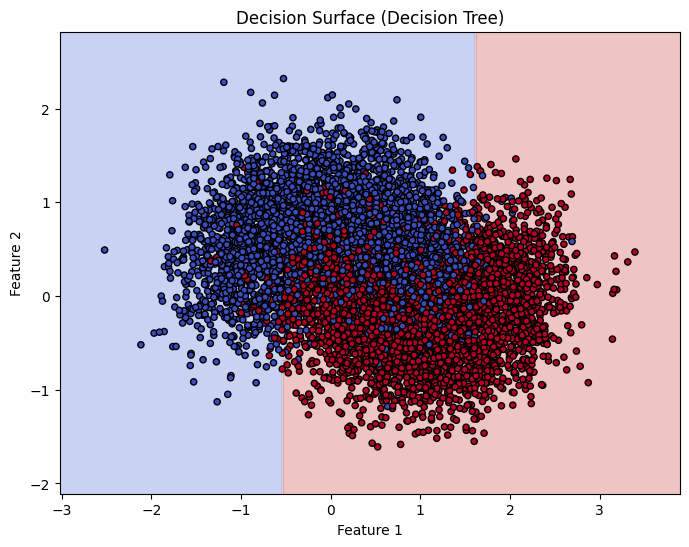

In [162]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Decision surface
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

# Training points
plt.scatter(x_train[:, 0], x_train[:, 1],
            c=y_train, cmap='coolwarm', s=20, edgecolor='k')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision Surface (Decision Tree)")
plt.show()


In [163]:
n_trees = 1000
cv = ShuffleSplit(n_splits=n_trees, train_size=100, random_state=42)


In [164]:
trees = []
for sets, _ in cv.split(x_train):
    x_subset = x_train[sets]
    y_subset = y_train[sets]
    tree = clone(grid.best_estimator_)
    tree.fit(x_subset, y_subset)
    trees.append(tree)

In [165]:
import numpy as np
single_tree_acc = np.mean([accuracy_score(y_test, tree.predict(x_test)) for tree in trees])
print(f"Average single accuracy:", single_tree_acc)

Average single accuracy: 0.7849565000000001


In [166]:
all_predictions = np.array([tree.predict(x_test) for tree in trees])
final_predictions, _ = mode(all_predictions, axis=0)
final_predictions = final_predictions.ravel()

In [167]:
forest_accuracy = accuracy_score(y_test, final_predictions)
print(f"Forest accuracy:{forest_accuracy}")

Forest accuracy:0.824
